In [34]:
from utils import * 
import json
import Bio.Entrez as entrez
from Bio.Align import PairwiseAligner
import itertools 
import networkx as nx
import subprocess

entrez.email = 'prichter@berkeley.edu'

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
GENOMES_DIR = '../data/genomes/'
GENES_DIR = '../data/genes/'

In [36]:
GENOME_CONTIG_IDS = dict()
GENOME_CONTIG_IDS['bz_0'] = []
GENOME_CONTIG_IDS['bz_1'] = ['Landfill_SRR22315504_scaffold_40513', 'Landfill_SRR22315504_scaffold_124901']
GENOME_CONTIG_IDS['bz_2'] = ['Dalian_Groundwater_SRR22387926_scaffold_5929']
GENOME_CONTIG_IDS['bz_3'] = ['Mangrove_60-80cm_incl_SRR17658263_scaffold_5020']
GENOME_CONTIG_IDS['bz_4'] = ['Nantong_Groundwater_SRR22387873_scaffold_1350']
GENOME_CONTIG_IDS['bz_5'] = ['Nantong_Groundwater_SRR22387873_scaffold_2044']
GENOME_CONTIG_IDS['bz_7'] = ['RifSed_csp1_16ft_4_scaffold_2135']
GENOME_CONTIG_IDS['bz_8'] = ['Shanghai_Industrial_Park_soil_SRR23875558_scaffold_1066']
GENOME_CONTIG_IDS['bz_9'] = ['SRR17498766_aquifer_sediment_scaffold_1816', 'SRR17498766_aquifer_sediment_scaffold_47226', 'SRR17498766_aquifer_sediment_scaffold_61411']
GENOME_CONTIG_IDS['bz_10'] = ['SRR17498766_aquifer_sediment_scaffold_6555', 'SRR17498766_aquifer_sediment_scaffold_7403', 'SRR17498766_aquifer_sediment_scaffold_93350']
GENOME_CONTIG_IDS['bz_11'] = ['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886', 'SR-VP_9_9_2021_31_2B_1_5m_scaffold_14874', 'SR-VP_9_9_2021_72_4B_1_05m_2_scaffold_578826', 'SR-VP_9_9_2021_56_4A_0_95m_scaffold_5485', 'SR-VP_9_9_2021_72_4B_1_05m_2_METASPADES_scaffold_91666']
GENOME_CONTIG_IDS['bz_12'] = ['Bodega_Bay_wetland_SRR22808026_scaffold_1073'] # Had to manually add this to the seed contigs FASTA file. 

GENOME_CONTIGS = {genome_id:FASTAFile.from_file(os.path.join(GENOMES_DIR, f'{genome_id}.fasta')).seqs[0] for genome_id in GENOME_CONTIG_IDS.keys()}
GENOME_SIZES = {genome_id:len(nt_seq) for genome_id, nt_seq in GENOME_CONTIGS.items()}
 
# Based on GC skew plots.
reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']


In [37]:
ORFM_MIN_LENGTH = 90

for path in glob.glob(os.path.join(GENOMES_DIR, '*')):
    genome_id = os.path.basename(path).replace('.fasta', '')
    aa_output_path = os.path.join(GENES_DIR, 'prodigal', f'{genome_id}.faa')
    nt_output_path = os.path.join(GENES_DIR, 'prodigal', f'{genome_id}.fna')
    if not os.path.exists(aa_output_path):
        subprocess.run(f'prodigal -a {aa_output_path} -d {nt_output_path} -i {path} -p meta', shell=True, check=True)

for path in glob.glob(os.path.join(GENOMES_DIR, '*')):
    genome_id = os.path.basename(path).replace('.fasta', '')
    aa_output_path = os.path.join(GENES_DIR, 'orfm', f'{genome_id}.faa')
    nt_output_path = os.path.join(GENES_DIR, 'orfm', f'{genome_id}.fna')
    if not os.path.exists(aa_output_path):
        subprocess.run(f'orfm -t {nt_output_path} {path} > {aa_output_path}', shell=True, check=True)

In [38]:

def _get_start_codon(codons, info):
    ''''''
    info['has_start_codon'] = np.any(np.isin(codons, START_CODONS))
    codons = codons[~np.isin(codons, STOP_CODONS)] # Exclude the stop codon so length_from_start_codon is correct. 
    if info['has_start_codon']:
        start_codon_idx = np.where(np.isin(codons, START_CODONS))[0][0]
        info['length_from_start_codon'] = len(codons) - start_codon_idx # Gets position of first start codon. 
        info['start_codon_idx'] = start_codon_idx
        info['start_codon'] = codons[start_codon_idx]
    return info

def _get_stop_codon(codons, info):
    ''''''
    info['has_stop_codon'] = np.any(np.isin(codons, STOP_CODONS))
    if info['has_stop_codon']:
        stop_codon_idx = np.where(np.isin(codons, STOP_CODONS))[0][0]
        info['stop_codon'] = codons[-1]
        assert codons[-1] in STOP_CODONS, f'_get_stop_codon: Expected the stop codon to be the last codon in the sequence, but it is at position {stop_codon_idx} of {len(codons)}.'
    return info

# I think OrfM has weird behavior at the terminal ends of the sequence, whereby it just treats the end of the contig as a stop codon if it finds a start codon 
# that is in-frame (based on behavior with bz_2_2_5_1, bz_1_3_6_2, etc.). In this case, then shifting the start or stop position might run off the end of the 
# contig rather than capturing the stop codon. 

def orfm_parse_entry(row):
    '''ORFm gene IDs are of the form {sequence_name}_{start}_{stop}_{frame}. The start coordinate is inclusive, so needs to be shifted by 1 to the left.
     See https://github.com/wwood/OrfM for more details.'''

    gene_id = row.gene_id.split('_')
    contig = GENOME_CONTIGS[get_genome_id(row.gene_id)] 

    # Not clear if the OrfM start position accounts for the stop codon when the gene is on the reverse strand.
    start, frame, gene_number = [int(x) for x in gene_id[-3:]] # The start coordinate is one-indexed, so will need to be shifted. 
    start = start - 1
    stop = start + (len(row.seq) * 3) # + 3 # The extra +3 accounts for the stop codon. 
    strand = '+' if (frame <= 3) else '-'
    
    partial = False
    if (strand == '-'):
        if (start - 3) < 0:
            partial = True 
        else:
            start = start - 3 # Adjust to include the stop codon. 
    elif (strand == '+'):
        if (stop + 3) > len(contig):
            partial = True 
        else:
            stop = stop + 3

    # row.nt_seq does not include the stop codon, but this should (assuming gene is not partial)
    nt_seq = reverse_complement(contig[start:stop]) if (strand == '-') else contig[start:stop]
    codons = np.array([nt_seq[i:i+3] for i in range(0, len(nt_seq), 3)])
    assert (len(nt_seq) % 3) == 0, f'orfm_parse_entry: Expected the nucleotide sequence to be divisible by three.' 

    num_codons = len(codons) - 1 if (not partial) else len(codons) # Adjust for the stop codon if not partial.
    assert num_codons == len(row.seq), f'orfm_parse_entry: Expected the number of codons ({num_codons}) to be the same length as the translated sequence ({len(row.seq)}).' 

    info = {'frame':frame, 'gene_number':gene_number, 'start':start, 'stop':stop, 'strand':strand, 'partial':partial}
    info = _get_start_codon(codons, info)
    info = _get_stop_codon(codons, info) 
    return info

def prodigal_parse_entry(row):
    '''Parse the info contained in the Prodigal output description line.'''
    header_pattern = r'# (?P<start>\d+) # (?P<stop>\d+) # (?P<strand>[\d\-]+) # ID\=\d+_(?P<gene_number>\d+)'
    info = re.search(header_pattern, row.description).groupdict()
    info['gene_number'], info['start'], info['stop'] = int(info['gene_number']), int(info['start']) - 1, int(info['stop'])
    info['partial'] = re.search(r'partial=(\d+)', row.description).group(1) != '00' # True if the partial string is not 00.
    info['strand'] = '+' if (info['strand'] == '1') else '-'
    info['start_codon'] = re.search(r'start_type=([^;]+)', row.description).group(1)
    info['length_from_start_codon'] = len(row.seq)
    return info


def load_genes(tool:str, parser=None, genome_ids=GENOME_CONTIG_IDS.keys()):
    genes_df = list()
    for genome_id in genome_ids:

        aa_df = FASTAFile.from_file(os.path.join(GENES_DIR, tool, f'{genome_id}.faa')).to_df() # Write the amino acid sequences to the FASTA file. 
        nt_df = FASTAFile.from_file(os.path.join(GENES_DIR, tool, f'{genome_id}.fna')).to_df().rename(columns={'seq':'nt_seq'}).drop(columns=['description'])
        df = pd.concat([nt_df, aa_df], axis=1).reset_index(names='gene_id')

        df_ = pd.DataFrame(df.apply(parser, axis=1).apply(pd.Series)) # Convert each dictionary to a pandas Series, and then to a DataFrame. 
        df = pd.concat([df, df_], axis=1)

        df['genome_id'] = genome_id
        df['seq'] = df.seq.str.replace('*', '') # Remove the terminal asterisk. 
        df['nt_seq'] = df.nt_seq.str.replace('*', '') # Remove the terminal asterisk.
        df['original_gene_id'] = df.gene_id 
        df['gene_id'] = [f'{tool}.{genome_id}.1_{int(row.gene_number)}' for row in df.itertuples()]
        genes_df.append(df)
    return pd.concat(genes_df).set_index('gene_id')

genes_df = load_genes('orfm', parser=orfm_parse_entry)

In [39]:
def _get_prodigal_gene(start:int=None, strand:str=None, stop:int=None, genome_id:str=None, genes_df_prodigal=None):
    '''For an OrfM prediction, get the Prodigal-predicted gene which is on the same strand, in the same frame, and overlaps'''
    mask = (genome_id == genes_df_prodigal.genome_id)
    mask = mask & (genes_df_prodigal.strand == strand) # Make sure ORFs are predicted on the same strand. 
    mask = mask & ((genes_df_prodigal.stop == stop) | (genes_df_prodigal.start == start))

    if mask.sum() == 0:
        return None
    if mask.sum() > 1:
        raise Exception(f'orfm_get_matching_prodigal_gene: Expecting only one corresponding Prodigal gene, but got {mask.sum()}.')
    return genes_df_prodigal[mask].iloc[0]


def get_prodigal_genes(genes_df, genes_df_prodigal=load_genes('prodigal', parser=prodigal_parse_entry)):

    for row in genes_df.itertuples():
        output = _get_prodigal_gene(start=row.start, stop=row.stop, strand=row.strand, genome_id=row.genome_id, genes_df_prodigal=genes_df_prodigal)
        if output is None:
            genes_df.loc[row.Index, 'prodigal_seq'] = output.seq if (output is not None) else '' 
            genes_df.loc[row.Index, 'prodigal_nt_seq'] = output.nt_seq if (output is not None) else '' 
            genes_df.loc[row.Index, 'prodigal_length_from_start_codon'] = row.length_from_start_codon
            continue 
        genes_df.loc[row.Index, 'prodigal_partial'] = output.partial
        genes_df.loc[row.Index, 'prodigal_gene_id'] = output.name
        genes_df.loc[row.Index, 'prodigal_length_from_start_codon'] = output.length_from_start_codon 
        genes_df.loc[row.Index, 'prodigal_seq'] = output.seq 
        genes_df.loc[row.Index, 'prodigal_nt_seq'] = output.nt_seq 
        genes_df.loc[row.Index, 'prodigal_start_idx'] = row.length_from_start_codon - output.length_from_start_codon

    counts = [(genes_df.prodigal_gene_id.values == gene_id).sum() for gene_id in genes_df_prodigal.index.unique()]
    assert np.all(np.array(counts) == 1), 'Every Prodigal gene ID should have exactly one corresponding OrfM sequence.'

    return genes_df


genes_df = get_prodigal_genes(genes_df)
genes_df['genome_size'] = genes_df.genome_id.map(GENOME_SIZES)


In [40]:
def trim_genes(genes_df:pd.DataFrame):
    genes_df['seq_untrimmed'] = genes_df.seq.copy()
    genes_df['nt_seq_untrimmed'] = genes_df.nt_seq.copy()
    genes_df['seq'] = [(row.seq[int(row.start_codon_idx):] if row.has_start_codon else row.seq) for row in genes_df.itertuples()]
    genes_df['nt_seq'] = [(row.nt_seq[int(row.start_codon_idx * 3):] if row.has_start_codon else row.nt_seq) for row in genes_df.itertuples()]
    genes_df['num_residues_trimmed'] = genes_df.seq_untrimmed.apply(len) - genes_df.seq.apply(len) 

    for row in genes_df.itertuples():
        if not row.has_start_codon:
            continue 
        assert row.nt_seq[:3] == row.start_codon, f'trim_sequence_to_start_codon: First codon is not the expected start codon. Saw {row.nt_seq[:3]}, expected {row.start_codon}.'
        assert len(row.seq) == row.length_from_start_codon, f'trim_sequence_to_start_codon: Sequence is not the expected length. Sequence has length {len(row.seq)}, expected {row.length_from_start_codon}.'
    n_trimmed = (genes_df.seq_untrimmed != genes_df.seq).sum()
    print(f'trim_genes: Trimmed {n_trimmed} of {len(genes_df)} genes to the first start codon.')
    return genes_df


def filter_genes(genes_df:pd.DataFrame, min_length:int=10):  
    masks = dict()
    masks['no_start_codon'] = (~genes_df.has_start_codon) & genes_df.prodigal_gene_id.isnull() # Keep genes without a start codon if Prodigal also predicts them to be partial.
    masks['no_stop_codon'] = (~genes_df.has_stop_codon) & genes_df.prodigal_gene_id.isnull() # Keep genes without a start codon if Prodigal also predicts them to be partial.
    masks['shorter_than_min_length'] = (genes_df.length_from_start_codon < min_length) & genes_df.has_start_codon 

    mask = None
    for name, mask_ in masks.items():
        print(f'filter_genes: Removing {mask_.sum()} genes failing filter {name}.')
        mask = mask_ if (mask is None) else mask | mask_
    genes_df = genes_df[~mask].copy()
    return genes_df


genes_df_untrimmed = genes_df.copy() # Store the unfiltered, untrimmed sequences. 
FASTAFile.from_df(genes_df_untrimmed).write(os.path.join(GENES_DIR, 'genes_untrimmed.faa'))

genes_df = filter_genes(trim_genes(genes_df)) # Store the filtered, trimmed sequences. 
FASTAFile.from_df(genes_df).write(os.path.join(GENES_DIR, 'genes.faa'))

for row in genes_df.itertuples():
    if (row.genome_id in reverse_complement_genome_ids):
        genes_df.loc[row.Index, 'start'] = row.genome_size - (row.stop + 1)
        genes_df.loc[row.Index, 'stop'] = row.genome_size - (row.start - 1) 
        genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'


genes_df.to_csv('../data/genes/genes.csv')

for genome_id, df in genes_df.groupby('genome_id'):
    path = f'../data/genes/orfm_trimmed/{genome_id}.faa'
    FASTAFile.from_df(df).write(path)

trim_genes: Trimmed 1656 of 2291 genes to the first start codon.
filter_genes: Removing 526 genes failing filter no_start_codon.
filter_genes: Removing 6 genes failing filter no_stop_codon.
filter_genes: Removing 126 genes failing filter shorter_than_min_length.


In [41]:
# All lengths here are in units of amino acids, not base pairs. 
df = genes_df[~genes_df.prodigal_gene_id.isnull()].copy()
df['length_difference'] = df.length_from_start_codon - df.prodigal_length_from_start_codon
df['length_difference_fraction'] = df.length_difference / df.length_from_start_codon

# With coverage mode 5, the alignment fraction of the shorter sequence is used; so for an alignment to be valid, it needs to cover 80% of the shorter sequence only. 

print('Maximum difference between Prodigal and first possible start:', df.length_difference.max())
print('Maximum difference (as a fraction of total length) between Prodigal and first possible start:', df.length_difference_fraction.max())
print('Number of genes where the length difference > 5 residues:', (df.length_difference > 5).sum())
print('Number of genes where the length difference (as a fraction of total length) > 20%:', (df.length_difference_fraction > 0.2).sum())
print('Mean difference between Prodigal-selected and first possible start:', df.length_difference.mean())

Maximum difference between Prodigal and first possible start: 35.0
Maximum difference (as a fraction of total length) between Prodigal and first possible start: 0.45714285714285713
Number of genes where the length difference > 5 residues: 27
Number of genes where the length difference (as a fraction of total length) > 20%: 4
Mean difference between Prodigal-selected and first possible start: 0.35664335664335667


In [42]:
borg_genome = FASTAFile.from_file('../data/Borg_family_members_contigs.fna').to_df().loc['Green_Borg_SRVP_2020_100_cm_2_FINAL-FINAL'].seq
borg_genome = FASTAFile.from_file('../data/Borg_family_members_contigs.fna').to_df().loc['Ochre_SR-VP_26_10_2020_2_100CM_FINAL_FINAL'].seq.upper()

borg_genome

'...'

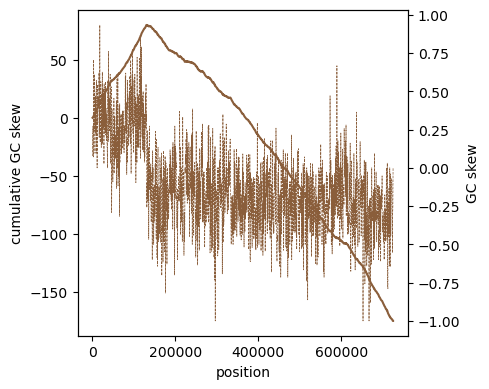

In [43]:
# https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008439

def get_gc_skew_info(nt_seq, window_size=2000, step_size=500, min_window_size=300, use_reverse_complement:bool=False):
    '''Preliminary inspection of the GC skew graphs indicates that all Betazoid genomes, like Borgs, have two uneven replichores.
    The current theory for Borg replication is that it begins at either terminus (the ITRs) and proceeds inwards; this would mean that the
    interior GC skew transition point is a ter. All genes on the forward strand prior to ter would be on the leading strand of one replichore, 
    and all genes on the reverse strand after ter would be on the leading strand of the other replichore.'''
    nt_seq = reverse_complement(nt_seq) if use_reverse_complement else nt_seq

    info = dict()

    genome_size = len(nt_seq)

    # Because one of the replichores are so short, a window size of 5000 does not pick up the sign change in GC skew. However, if the window size is
    # decreased, GC skew becomes too noisy. To fix this, just adjusted the window sizes to be shorter at either ITR.

    n = ((window_size - min_window_size) // step_size) + 1 # The number of shorter windows to add at the left end. 
    # print(f'get_gc_skew_info: Splitting the {window_size} bp region at the left terminus into {n} windows.')

    window_starts = [0] * n 
    window_stops = list(range(min_window_size, window_size + 1, step_size))
    assert len(window_starts) == len(window_stops), f'get_gc_skew_info: There are {len(window_starts)} starts and {len(window_stops)} stops.'
    window_starts = np.array(window_starts + list(range(window_size, genome_size, step_size)))
    window_stops = np.array(window_stops + [min(genome_size, i + window_size) for i in range(window_size, genome_size, step_size)])
    assert len(window_starts) == len(window_stops), f'get_gc_skew_info: There are {len(window_starts)} starts and {len(window_stops)} stops.'
    
    windows = np.array([nt_seq[start:stop] for start, stop in zip(window_starts, window_stops)])

    mask = np.array([len(window) for window in windows]) > min_window_size
    window_starts = np.array(window_starts[mask]).copy()
    window_stops = np.array(window_stops[mask]).copy()
    windows = windows[mask].copy()

    # print(f'get_gc_skew_info: Discarding {(~mask).sum()} windows shorter than {min_window_size} bp')
    # print(f'get_gc_skew_info: {(window_starts == 0).sum()} windows starting at position 0.')
    # print(f'get_gc_skew_info: {(window_stops == genome_size).sum()} windows ending at position {genome_size}.')

    info['window_midpoints'] = (window_stops + window_starts) / 2
    info['window_midpoints_relative'] = info['window_midpoints'] / genome_size
    info['window_starts'] = window_starts
    info['window_stops'] = window_stops
    info['window_starts_relative'] = window_starts / genome_size

    _get_gc_skew = lambda window : (window.count('G') - window.count('C')) / (window.count('G') + window.count('C'))
    info['gc_skews'] = np.array([_get_gc_skew(window) for window in windows]) # One GC skew per window. 
    info['gc_skews_cumulative'] = np.cumsum(info['gc_skews'])

    info['gc_skew_transition_idxs'] = np.where(np.diff(np.sign(info['gc_skews'])) != 0)[0]
    return info

# Unsure why the correct ter GC skew flip is not registering for bz_0; possible that the small replichore is too short.
# Inspection of the gene orientations indicates that it should be reverse-complemented for ter to be on the correct side, so did this manually. 
# Ultimately decided to locate all GC skew transitions manually to be safe. 

# The template strand should be G-depleted, so GC skew should be decreasing (more negative) over the replicon, assuming replication proceeds 
# from the termini. 

genome_ids = list(GENOME_CONTIG_IDS.keys())
fig, ax_1 = plt.subplots(figsize=(5, 4))
ax_2 = ax_1.twinx()

for genome_id in genome_ids:
    if genome_id == 'bz_12':
        continue
    if genome_id != 'bz_0':
        continue
    genome = reverse_complement(GENOME_CONTIGS[genome_id])
    genome = borg_genome

    info = get_gc_skew_info(genome, use_reverse_complement=(genome_id in reverse_complement_genome_ids), window_size=100, min_window_size=50)
    ax_1.plot(info['window_midpoints'], info['gc_skews_cumulative'], color=GENOME_ID_COLORS[genome_id], label=genome_id)
    ax_2.plot(info['window_midpoints'], info['gc_skews'], color=GENOME_ID_COLORS[genome_id], label=genome_id, ls='--', lw=0.5)

ax_1.set_ylabel('cumulative GC skew')
ax_2.set_ylabel('GC skew')

ax_1.set_xlabel('position')
# ax.legend()
fig.tight_layout()
plt.show() 
    
    

In [44]:
TRF_OUTPUT_DIR = '../data/trf'
TRF_COMMAND = 'trf {path} {match} {mismatch} {delta} {match_probability} {indel_probability} {min_score} {max_period}  -h'
# trf <sequence.fasta> <match> <mismatch> <delta> <PM> <PI> <Minscore> <MaxPeriod>
# PM is match probability, PI is insertion/deletion probability, delta is the indel penalty. 
TRF_PARAMS = dict()
TRF_PARAMS['match'] = 2
TRF_PARAMS['mismatch'] = 7
TRF_PARAMS['delta'] = 7
TRF_PARAMS['match_probability'] = 80
TRF_PARAMS['indel_probability'] = 10
TRF_PARAMS['min_score'] = 15
TRF_PARAMS['max_period'] = 50

for path in glob.glob('../data/genomes/*fasta'):
    cmd = TRF_COMMAND.format(path=os.path.abspath(path), **TRF_PARAMS)
    print(cmd)
    subprocess.run(cmd, shell=True, check=True,stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)

for path in glob.glob('./*dat'):
    genome_id = get_genome_id(path)
    output_path = os.path.abspath(f'../data/trf/{genome_id}.dat')
    subprocess.run(f'mv {path} {output_path}', shell=True, check=True)

trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_0.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_10.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_3.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_11.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_9.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_5.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_12.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_4.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_1.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_8.fasta 2 7 7 80 10 15 50  -h
trf /home/prichter/Documents/banfield/betazoid/data/genomes/bz_7.fa

In [45]:
genes_df[~genes_df.prodigal_gene_id.isnull()].seq.apply(len).min()

np.int64(31)

In [46]:
# The only difference between the qtmscore and ttmscore is the normalization factor (relative to the target or query length).
# The TM score formula is (1 / L) * sum(1 / (1 + (d_i/d_0(L))**2)), where d_i is the distance between the aligned residues after superposition of structures and d_0 is a length-dependent scaling factor
# that increases with protein size. L is the length of the protein (the query in the case of qtmscore, or target in the case of ttmscore).

# Why am I getting hits on the Foldseek Search browser interface, but not from the server? The database versions seem to be the same.
# I think the problem was the alignment-type parameter. It had been --alignment-type 2, which essentially just aligns the 3Di structure strings
# rather than the actual structures (coordinate-based).

# The "prob" value is derived from a classifier which takes alignment features (e.g. E-value, TM score, etc.) as input and outputs a confidence value (the prob score).

# LDDT (local distance difference test) is the average of the per-residue local similarity scores. 
# This differs from the TM score, which measures the global similarity between two structures. 

# What does it mean when the LDDT score is lower than the TM score? Shouldn't it be higher, generally?

FOLDSEEK_SEARCH_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
foldseek_search_target_database_pattern = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(foldseek_search_target_database_pattern, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(foldseek_search_target_database_pattern, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_SEARCH_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df.drop_duplicates(['query', 'target'])

In [47]:
# NCBI_BLASTP_FILE_PATTERN = '(3R|3V).+' # Load only results from the trimmed proteins. 

# ncbi_blast_df = pd.concat([BLASTFileJSON.from_file(path).to_df() for path in glob.glob('../data/ncbi/blastp/*') if re.match(NCBI_BLASTP_FILE_PATTERN, os.path.basename(path))])
# ncbi_blast_df = ncbi_blast_df[ncbi_blast_df.bit_score > 45].copy()
# # ncbi_blast_df['gene_id'] = ncbi_blast_df['id'].map(genes_df.reset_index(drop=False).set_index('original_gene_id').gene_id)
# ncbi_blast_df['gene_id'] = ncbi_blast_df['id']
# ncbi_blast_df = ncbi_blast_df[~ncbi_blast_df.gene_id.isnull()].copy()
# ncbi_blast_df['genome_id'] = [gene_id.split('.')[1] for gene_id in ncbi_blast_df.gene_id]
# ncbi_blast_df['percent_identity'] = 100 * ncbi_blast_df.identity / ncbi_blast_df.alignment_length

# genes_df['has_ncbi_blast_hit'] = genes_df.index.isin(ncbi_blast_df.gene_id.unique())
# # archaeal_taxa = ['Promethearchaeota archaeon', 'Candidatus Methanoperedens sp.', 'Candidatus Micrarchaeaceae archaeon', 'Candidatus Pacearchaeota archaeon', 'Thermoplasmata archaeon', 'uncultured archaeon', 'Nanobdellota archaeon', 'Candidatus Aenigmatarchaeota archaeon', 'Candidatus Woesearchaeota archaeon', 'Thermoplasmatota archaeon', 'Promethearchaeia archaeon', 'Candidatus Parvarchaeota archaeon', 'Caldisphaera sp.', 'Candidatus Rehaiarchaeum fermentans', 'Candidatus Bathyarchaeia archaeon', 'Candidatus Bathyarchaeota archaeon', 'Methanobacterium sp.', 'Methanobacteriota archaeon', 'Candidatus Nanoarchaeia archaeon', 'Candidatus Thorarchaeota archaeon', 'Thermofilaceae archaeon', 'Candidatus Nitrosopumilus sp.', 'Methanolobus sp.', 'Methanosarcinales archaeon', 'Microcaldota archaeon', 'archaeon', 'Nitrososphaerota archaeon', 'Conexivisphaerales archaeon', 'Candidatus Parvarchaeum sp.', 'Nitrososphaeria archaeon', 'Candidatus Methanospirareceae archaeon', 'Candidatus Thorarchaeota archaeon SMTZ1-45', 'Candidatus Thorarchaeota archaeon SMTZ-45', 'Candidatus Njordarchaeota archaeon', 'Thermococci archaeon', 'Archaeoglobales archaeon', 'Sulfolobales archaeon', 'Candidatus Poseidoniia archaeon', 'uncultured marine crenarchaeote HF4000_APKG2O16', 'Candidatus Methanogasteraceae archaeon', 'Halobellus ruber', 'Halosimplex aquaticum', 'Candidatus Micrarchaeales archaeon', 'Methanomassiliicoccales archaeon', 'Methanogenium sp.', 'Thermoproteota archaeon', 'uncultured archaeon A07HR60', 'Candidatus Kariarchaeaceae archaeon', 'Candidatus Hodarchaeales archaeon', 'Candidatus Methanoperedens sp. BLZ2', 'Nitrosopumilaceae archaeon']

# print('Number of proteins with an NCBI BLAST hit:', genes_df.has_ncbi_blast_hit.sum())
# print('Number of clusters with an NCBI BLAST hit:', genes_df.drop_duplicates('cluster_id').cluster_has_ncbi_blast_hit.sum())
# print('Number of proteins in clusters with an NCBI BLAST hit:', genes_df.cluster_has_ncbi_blast_hit.sum())
# # for genome_id, df in ncbi_blast_df.groupby('genome_id'):
# #     df = df.sort_values('archaeal').drop_duplicates('gene_id') # Preferentially keep hits to archaeal proteins.
# #     print(f'\t{genome_id}: {df.gene_id.nunique()}, {df.archaeal.sum()} hits to archaeal proteins')


In [48]:
NCBI_PROTEINS_DIR = '../data/ncbi/proteins'
NCBI_PROTEINS_PATH = '../data/ncbi/proteins.csv'
    
protein_ids = ncbi_blast_df.subject_id.unique() # Download using the download_ncbi function. 

if not os.path.exists(NCBI_PROTEINS_PATH):
    ncbi_proteins_df = list()
    for path in tqdm(glob.glob(os.path.join(NCBI_PROTEINS_DIR, '*')), f'Loading NCBI proteins from {NCBI_PROTEINS_DIR}.'):
        protein_id = os.path.basename(path).replace('.gbk', '')
        if protein_id not in ncbi_blast_df.subject_id.unique():
            continue

        ncbi_proteins_df.append(GenBankFile.from_file(path).to_df().assign(path=path))
    ncbi_proteins_df = pd.concat(ncbi_proteins_df)
    ncbi_proteins_df.to_csv(NCBI_PROTEINS_PATH, index=False)
else:
    ncbi_proteins_df = pd.read_csv(NCBI_PROTEINS_PATH)

get_domain = lambda organism : re.search('Bacteria|Archaea|Eukaryota', organism).group(0) if (re.search('Bacteria|Archaea|Eukaryota', organism) is not None) else 'none'

# https://www.ncbi.nlm.nih.gov/genbank/unverified/
ncbi_proteins_df = ncbi_proteins_df[ncbi_proteins_df.feature_type == 'Protein'].copy()
ncbi_proteins_df['domain'] = ncbi_proteins_df.organism.apply(get_domain)

print('Number of downloaded proteins:', ncbi_proteins_df.locus_id.nunique())

NameError: name 'ncbi_blast_df' is not defined

In [ ]:
NCBI_CONTIGS_DIR = '../data/ncbi/contigs'
NCBI_CONTIGS_PATH = '../data/ncbi/contigs.csv' 

# The contig ID is always the last thing in the entry. Also need to remove the version indicator.
get_contig_id = lambda dbsource : None if (pd.isnull(dbsource)) else dbsource.split()[-1].split('.')[0]

contig_ids = ncbi_proteins_df.dbsource.dropna().apply(get_contig_id).values
# Get only the contig IDs which were successfully downloaded by the download_ncbi function. 
contig_paths = {contig_id:os.path.join(NCBI_CONTIGS_DIR, f'{contig_id}.gbk') for contig_id in contig_ids if os.path.exists(os.path.join(NCBI_CONTIGS_DIR, f'{contig_id}.gbk'))}


def get_contig_metadata(path, tag:str='SOURCE'):
    '''Read a metadata line from the GenBank file header without loading the entire file into memory.'''
    f = open(path, 'r')

    line = f.readline()
    metadata = None
    while not line.startswith('FEATURES'):
        if line.startswith(tag):
            metadata = line.replace(tag, '').strip()
            break 
        line = f.readline()
    f.close()
    return metadata

get_contig_length = lambda path : int(re.search(r'(\d+) bp', get_contig_metadata(path, tag='LOCUS')).group(1))


def get_contig_gc_content(path):
    try: # Fails when there is no ORIGIN section in the file, just a Join(...) statement.
        contig = list(GenBankFile.from_file(path, load_origins_only=True).origins.values())
        assert len(contig) == 1, f'get_contig_gc_content: Expected 1 contig, but found {len(contig)} contigs in {contig}'
        assert len(contig[0]) > 0, f'get_contig_gc_content: Contig is empty.'
    except Exception as err:
        print(f'get_contig_gc_content: Failed to parse file {path}, {err}')
        return None 
    contig = contig[0].upper()
    return (contig.count('G') + contig.count('C')) / len(contig)


if not os.path.exists('../data/ncbi/contig_gc_contents.json'):
    contig_gc_contents = {contig_id:get_contig_gc_content(path) for contig_id, path in tqdm(list(contig_paths.items()), desc='Computing contig GC contents.')}
    with open('../data/ncbi/contig_gc_contents.json', 'w') as f:
        json.dump(contig_gc_contents, f)
else:
    with open('../data/ncbi/contig_gc_contents.json', 'r') as f:
        contig_gc_contents = json.load(f)


ncbi_proteins_df['contig_id'] = ncbi_proteins_df.dbsource.apply(get_contig_id) 
ncbi_proteins_df['contig_gc_content'] = ncbi_proteins_df.contig_id.map(contig_gc_contents)
ncbi_proteins_df['contig_length'] = ncbi_proteins_df.contig_id.map({contig_id:get_contig_length(path) for contig_id, path in contig_paths.items()})
ncbi_proteins_df['contig_definition'] = ncbi_proteins_df.contig_id.map({contig_id:get_contig_metadata(path, tag='DEFINITION') for contig_id, path in contig_paths.items()})

print('Number of contigs with computed GC contents:', (~ncbi_proteins_df.drop_duplicates('contig_id').contig_gc_content.isnull()).sum())
print('Number of contigs:', ncbi_proteins_df.contig_id.nunique())

mask = (ncbi_proteins_df.contig_gc_content < 0.3) & (ncbi_proteins_df.contig_length < 25000) & ncbi_proteins_df.contig_definition.str.contains('MAG', case=False)
print('Number of contigs flagged as possibly mis-binned:', ncbi_proteins_df[mask].locus_id.nunique())
ncbi_blast_df = ncbi_blast_df[~ncbi_blast_df.subject_id.isin(ncbi_proteins_df[mask].locus_id.values)].copy() # Remove untrustworthy BLAST hits.

Number of contigs with computed GC contents: 1765
Number of contigs: 1810
Number of contigs flagged as possibly mis-binned: 62


In [ ]:
EXCLUDE_DISORDER_PREDICTIONS = False
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
# annot_df_unfiltered = pd.read_csv('../data/genes/genes_untrimmed.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)

if EXCLUDE_DISORDER_PREDICTIONS:
    annot_df = annot_df[annot_df.analysis != 'MobiDBLite'].copy()
    # annot_df_unfiltered = annot_df_unfiltered[annot_df_unfiltered.analysis != 'MobiDBLite'].copy()

genes_df['has_annotation'] = genes_df.index.isin(annot_df.gene_id.unique())
genes_df['cluster_has_annotation'] = genes_df.groupby('cluster_id')['has_annotation'].transform('any')
# genes_df['annotated_consensus_disorder_only'] = genes_df.index.map(annot_df.groupby('gene_id').apply(lambda df : np.all(df.analysis == 'MobiDBLite'), include_groups=False))
genes_df['annotation_start'] = genes_df.index.map(annot_df.groupby('gene_id').annotation_start.min())
genes_df['annotation_stop'] = genes_df.index.map(annot_df.groupby('gene_id').annotation_stop.max())
annot_df['genome_id'] = [gene_id.split('.')[1] for gene_id in annot_df.gene_id]


print('Number of genes with any annotation:',  genes_df.has_annotation.sum())
print('Number of clusters with any annotation:', genes_df.drop_duplicates('cluster_id').cluster_has_annotation.sum())
print('Number of genes in clusters with any annotation:', genes_df.cluster_has_annotation.sum())

print()
for signature_accession, df in annot_df[~annot_df.analysis.isin(['Coils', 'MobiDBLite'])].groupby('signature_accession'):
    n_genomes = df.genome_id.nunique()
    signature_description = df.iloc[0].signature_description
    interpro_description = df.iloc[0].interpro_description
    if n_genomes < 3:
        continue 
    print(f'{n_genomes} genomes with an annotation for {signature_accession} {signature_description}, {interpro_description}')


Number of genes with any annotation: 97
Number of clusters with any annotation: 68
Number of genes in clusters with any annotation: 126

10 genomes with an annotation for G3DSA:3.30.420.10 -, Ribonuclease H superfamily
6 genomes with an annotation for G3DSA:3.40.50.300 -, P-loop containing nucleoside triphosphate hydrolase
11 genomes with an annotation for G3DSA:3.90.1600.10 Palm domain of DNA polymerase, DNA polymerase, palm domain superfamily
12 genomes with an annotation for PF03175 DNA polymerase type B, organellar and viral, DNA-directed DNA polymerase, family B, mitochondria/virus
5 genomes with an annotation for PR00106 DNA-directed DNA-polymerase family B signature, DNA-directed DNA polymerase, family B
5 genomes with an annotation for PS00116 DNA polymerase family B signature., DNA-directed DNA polymerase, family B, conserved site
5 genomes with an annotation for PS51257 Prokaryotic membrane lipoprotein lipid attachment site profile., -
11 genomes with an annotation for PTHR33

In [ ]:
# # Analyze signal peptides... Worth comparing results from both SignalP v6 and v5.

# SIGNALP_V5_FIELDS = ['position', 'amino_acid', 'prediction', 'signal_peptide_probability', 'cleavage_site_probability', 'other_probability']
# SIGNALP_V6_FIELDS = ['gene_id', 'prediction', 'other_probability', 'sp_probability', 'lipo_probability', 'tat_probability', 'tatlipto_probability', 'pilin_probability', 'cleavage_site_position']	
# SIGNALP_V5_DIR = '../data/genes/signalp/v5/'
# SIGNALP_V6_PATH = '../data/genes/signalp/v6/prediction_results.txt'


# load_signalp = lambda path, fields: pd.read_csv(path, comment='#', sep='\t', engine='python', names=fields)
# count_signalp = lambda df : df[df.prediction.isin(['S', 'SP', 'LIPO'])].gene_id.nunique()

# signalp_v5_df = pd.concat([load_signalp(path, SIGNALP_V5_FIELDS).assign(gene_id=get_gene_id(path)) for path in tqdm(glob.glob(os.path.join(SIGNALP_V5_DIR, '*txt')), desc=f'Loading SignalP output from {SIGNALP_V5_DIR}.')])
# signalp_v6_df = load_signalp(SIGNALP_V6_PATH, SIGNALP_V6_FIELDS)

# signalp_v5_df['genome_id'] = signalp_v5_df.gene_id.apply(get_genome_id)
# signalp_v6_df['genome_id'] = signalp_v6_df.gene_id.apply(get_genome_id)

# print('Number of proteins with signal peptides:', count_signalp(signalp_v5_df), count_signalp(signalp_v6_df))
# for genome_id in signalp_v5_df.genome_id.unique():
#     num_sp_v5 = count_signalp(signalp_v5_df[signalp_v5_df.genome_id == genome_id].copy())
#     num_sp_v6 = count_signalp(signalp_v6_df[signalp_v6_df.genome_id == genome_id].copy())
#     print(f'\tNumber of proteins with signal peptides in {genome_id}:', num_sp_v5, num_sp_v6)

# genes_df['has_signal_peptide'] = genes_df.index.isin(signalp_v6_df[signalp_v6_df.prediction != 'OTHER'].gene_id.unique()) # Opted to use the SignalP version 6 predictions.


In [ ]:
min_num_genomes = 3
mask = (genes_df.genome_id == 'bz_7') & ((genes_df.start < 400) | (genes_df.stop > 14800))
print(f'\nExcluding {mask.sum()} proteins in the weird repeat region of bz_7.') # These are all annotated, but are super degenerate, and I think probably false positives.

table_df = genes_df[~mask].drop_duplicates('cluster_id').set_index('cluster_id').copy()
table_df['predicted_by_prodigal'] = genes_df.groupby('cluster_id')['prodigal_gene_id'].apply(lambda s: s.notna().any())
# figure_df['cluster_all_predicted_by_prodigal'] = genes_df.groupby('cluster_id')['prodigal_gene_id'].apply(lambda s: s.notna().all())
table_df['has_ncbi_blast_hit'] = genes_df.groupby('cluster_id')['has_ncbi_blast_hit'].apply('any')
table_df['has_annotation'] = genes_df.groupby('cluster_id')['has_annotation'].apply('any')
table_df['has_tmh'] = genes_df.groupby('cluster_id')['has_tmh'].apply('any')
table_df[f'num_genomes_at_least_{min_num_genomes}'] = table_df.cluster_num_genomes > (min_num_genomes - 1)

groups = ['predicted_by_prodigal', 'has_ncbi_blast_hit', 'has_annotation', 'has_tmh', f'num_genomes_at_least_{min_num_genomes}']
table_df = table_df.groupby(groups).size()
table_df = table_df.reset_index(name='count')
table_df[~table_df['predicted_by_prodigal']]



Excluding 29 proteins in the weird repeat region of bz_7.


,predicted_by_prodigal,has_ncbi_blast_hit,has_annotation,has_tmh,num_genomes_at_least_3,count
0,False,False,False,False,False,729
1,False,False,False,False,True,2
2,False,False,False,True,False,392
3,False,False,False,True,True,1
4,False,False,True,False,False,10
5,False,False,True,True,False,2
6,False,True,False,False,False,5
7,False,True,False,True,False,1


In [ ]:

# dna_polymerase_b_gene_ids = annot_df[annot_df.interpro_description.str.contains('polymerase')].gene_id.unique() 
# mmseqs_cluster_df[mmseqs_cluster_df.gene_id.isin(dna_polymerase_b_gene_ids)]

# def get_pairwise_identity(seqs):

#     n = len(seqs)
#     df = pd.DataFrame(np.zeros((n, n)), columns=seqs.index, index=seqs.index)
#     for ((id_1, seq_1), (id_2, seq_2)) in itertools.combinations(seqs.to_dict().items(), 2):
#         alignment = PairwiseAligner().align(seq_1, seq_2)[0]
#         df.loc[id_1, id_2] = alignment.score / min(len(seq_1), len(seq_2))
#         df.loc[id_2, id_1] = alignment.score / min(len(seq_1), len(seq_2))
#     return df

# get_pairwise_identity(genes_df.loc[dna_polymerase_b_gene_ids].seq)


# Checked length of 'orfm.bz_4.1_107', and the OrfM predicted length is the same as the Prodigal-predicted length. 


In [ ]:
# The ece.protein.faa file contains all proteins from the following projects:
#   (1) https://ggkbase.berkeley.edu/Borg_family_members/
#   (2) https://ggkbase.berkeley.edu/mp_ece/
#   (3) https://ggkbase.berkeley.edu/project_groups/borg-methanoperedens
#   (4) https://ggkbase.berkeley.edu/project_groups/borgs_mp_nanopore

# annot_df_unfiltered = annot_df_unfiltered[~annot_df_unfiltered.gene_id.isin(annot_df.index.unique())].copy() # Remove genes which already have annotations.
# annot_df_unfiltered['gene_removed_by_filter'] = ~annot_df_unfiltered.gene_id.isin(genes_df.index.unique())
# annot_df_unfiltered['has_annotation_when_trimmed'] = annot_df_unfiltered.gene_id.isin(annot_df.gene_id.unique()) 
# annot_df_unfiltered['num_residues_trimmed'] = annot_df_unfiltered.gene_id.map(genes_df.num_residues_trimmed)

# # All proteins removed by filter with an annotation are part of the bz_7 weird repeat region, so maybe false positive. 
# # Some of the proteins which only have an annotation when trimmed are potentially interesting, especially orfm.bz_3.1_103, but there are hardly any.  
# print('\nNum. proteins removed by filter with an annotation:', annot_df_unfiltered[annot_df_unfiltered.gene_removed_by_filter].gene_id.nunique())
# print('Num. proteins not removed by filter which have an annotation only when untrimmed:', annot_df_unfiltered[~annot_df_unfiltered.gene_removed_by_filter & ~annot_df_unfiltered.has_annotation_when_trimmed].gene_id.nunique())

In [ ]:
# fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# figure_df = genes_df.groupby('genome_id').size().reset_index(name='n_genes')
# figure_df['n_genes_forward_strand'] = figure_df.genome_id.map(genes_df[genes_df.strand == '+'].groupby('genome_id').size())
# figure_df['n_genes_reverse_strand'] = figure_df.genome_id.map(genes_df[genes_df.strand == '-'].groupby('genome_id').size())

# ax = axes[0]
# ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_forward_strand, label='+', color='steelblue')
# ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_reverse_strand, bottom=figure_df.n_genes_forward_strand, label='-', color='lightblue')
# ax.legend()
# ax.set_xticks(np.arange(len(figure_df)), labels=figure_df.genome_id, rotation=90)

# figure_df = genes_df[~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size().reset_index(name='n_genes')
# figure_df['n_genes_forward_strand'] = figure_df.genome_id.map(genes_df[(genes_df.strand == '+') & ~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size())
# figure_df['n_genes_reverse_strand'] = figure_df.genome_id.map(genes_df[(genes_df.strand == '-') & ~genes_df.prodigal_gene_id.isnull()].groupby('genome_id').size())
# figure_df = figure_df.fillna(0) # For cases where there are no genes on one of the strands (bz_12)

# ax = axes[1]
# ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_forward_strand, label='+', color='firebrick')
# ax.bar(x=np.arange(len(figure_df)), height=figure_df.n_genes_reverse_strand, bottom=figure_df.n_genes_forward_strand, label='-', color='indianred')
# ax.legend()
# ax.set_xticks(np.arange(len(figure_df)), labels=figure_df.genome_id, rotation=90)

# fig.tight_layout()
# plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(4, 3))

# figure_df = genes_df.copy()
# figure_df['length'] = figure_df.seq.apply(len)

# sns.ecdfplot(figure_df, x='length', hue='genome_id', ax=ax, palette='Blues', legend=False)
# sns.ecdfplot(figure_df[~figure_df.prodigal_gene_id.isnull()], x='length', hue='genome_id', palette='Reds', ax=ax, legend=False)
# ax.set_xlim(xmin=0)
# ax.set_ylabel('proportion')
# ax.set_title('predicted gene lengths')
# ax.legend(handles=[Patch(facecolor='steelblue'), Patch(facecolor='indianred')], labels=['OrfM', 'Prodigal'])

# plt.show()

In [ ]:
# # Also want to look at GC content of various genes...

# get_gc_percent = lambda nt_seq : 100 * (nt_seq.count('G') + nt_seq.count('C')) / len(nt_seq)

# figure_df = genes_df.copy()
# figure_df['gc_percent'] = figure_df.nt_seq.apply(get_gc_percent)
# # figure_df['genome_id'] = [gene_id.split('.')[1] for gene_id in figure_df.gene_id]
# figure_df['genome_gc_percent'] = figure_df.genome_id.map({genome_id:get_gc_percent(nt_seq) for genome_id, nt_seq in GENOME_CONTIGS.items()})

# fig, ax = plt.subplots(figsize=(4, 3))

# # sns.stripplot(figure_df, x='genome_id', y='gc_percent', color='steelblue', ax=ax, alpha=1, s=3)
# sns.stripplot(figure_df[~figure_df.prodigal_gene_id.isnull()], x='genome_id', y='gc_percent', color='steelblue', ax=ax, alpha=1, s=3)
# ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)
# ax.set_xlabel('')
# ax.set_ylabel('GC percent')
# ax.axhline(40, ls='--', color='black', lw=0.7)
# plt.show()

In [ ]:
# G3DSA:3.90.1600.10 Palm domain of DNA polymerase
# PR00106 DNA-directed DNA-polymerase family B signature
# SSF56672 DNA/RNA polymerases
# PTHR33568 DNA POLYMERASE
# PF03175 DNA polymerase type B, organellar and viral

# G3DSA:1.10.260.40	Lambda repressor-like DNA-binding protein
# SSF47413 lambda repressor-like DNA-binding domains
# PS50943 Cro/C1-type HTH domain profile
# cd00093 Helix-turn-helix
# PF01381 HTH_XRE

# G3DSA:3.30.420.10 Ribonuclease H superfamily
# SSF53098 Ribonuclease H-like

# G3DSA:3.40.50.300 P-loop containing nucleoside triphosphate hydrolase
# SSF52540 P-loop containing nucleoside triphosphate hydrolase

# SSF49464 Carboxypeptidase regulatory domain-like
# G3DSA:2.60.120.260
# PF13620 Carboxypeptidase regulatory-like domain


In [ ]:
# # First want to evaluate the quality of the ColabFold structures. 
# COLABFOLD_DIR = '../data/genes/colabfold/'
# COLABFOLD_PDB_FILE_NAME_PATTERN = r'*_relaxed_rank_001_alphafold2_ptm_model*.pdb'
# COLABFOLD_SCORES_FILE_NAME_PATTERN = r'*_scores_rank_001_alphafold2_ptm_model*.json'

# COLABFOLD_PLDDTS = dict()

# # (1) plDDT: Averaged per-residue confidence averaged, which is a measure of model confidence in local structure. 
# # (2) pTM is the predicted TM score, which is a measure global fold confidence, and is computed from PAE. TM is really a measure of similarity between
# #       two structures. In the case of ColabFold output, because there is no reference structure, it is communicating the expected TM score if the predicted structure
# #       were compared to the hypothetical ground-truth structure.
# # (3) PAE is predicted aligned error, and is fundamentally a pairwise matrix. Each element i, j is the confidence in the expected position of residue j if residue i is
# #       treated as an anchor. This measures confidence in the relative positioning of different domains (long-range structure).

# def load_colabfold_scores(dir_:str=COLABFOLD_DIR):
#     df = list()
#     for path in glob.glob(os.path.join(dir_, '*', COLABFOLD_SCORES_FILE_NAME_PATTERN)):
#         with open(path, 'r') as f:
#             scores = json.load(f)
#         plddts = np.array(scores['plddt'])

#         COLABFOLD_PLDDTS[get_gene_id(path)] = plddts
#         info = dict()
#         info['gene_id'] = get_gene_id(path)
#         info['mean_plddt'] = np.mean(plddts)
#         info['min_plddt'] = np.min(plddts)
#         info['max_plddt'] = np.max(plddts)
#         info['length'] = len(plddts)
#         info['ptm'] = scores['ptm']
#         info['fraction_plddt_greater_than_50'] = (plddts > 50).mean()
#         info['fraction_plddt_greater_than_70'] = (plddts > 70).mean()
#         info['fraction_plddt_greater_than_90'] = (plddts > 90).mean()
#         df.append(info)
#     df = pd.DataFrame(df)
#     return df.set_index('gene_id')

# colabfold_scores_df = load_colabfold_scores()
# genes_df = genes_df.merge(colabfold_scores_df, left_index=True, right_index=True)


In [ ]:
# FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/genes'
# COLABFOLD_FILE_NAME_PATTERN = '*_relaxed_rank_001_alphafold2_ptm_model*'

# # foldseek easy-cluster /home/prichter/Documents/banfield/betazoid/data/genes/foldseek/input/ /home/prichter/Documents/banfield/betazoid/data/genes/foldseek/genes /home/prichter/Documents/banfield/betazoid/data/tmp --tmscore-threshold 0.5 --cov-mode 5 -c 0.8
# foldseek_cluster_df = pd.read_csv('../data/genes/foldseek/genes_cluster.tsv', sep='\t', header=None, names=['rep_gene_id', 'gene_id'])
# foldseek_cluster_df['gene_id'] = [re.search(r'orfm.bz_\d+\.\d_\d+', gene_id).group(0) for gene_id in foldseek_cluster_df.gene_id]
# foldseek_cluster_df['genome_id'] = [re.search(r'bz_\d+', gene_id).group(0) for gene_id in foldseek_cluster_df.gene_id]
# foldseek_cluster_df['cluster_size'] = foldseek_cluster_df.rep_gene_id.map(foldseek_cluster_df.groupby('rep_gene_id').size())
# foldseek_cluster_df['cluster_num_genomes'] = foldseek_cluster_df.rep_gene_id.map(foldseek_cluster_df.groupby('rep_gene_id').genome_id.nunique())
# foldseek_cluster_df = foldseek_cluster_df.sort_values('cluster_num_genomes', ascending=False) # Make it so the largest cluster is first. 
# foldseek_cluster_df['cluster_id'] = pd.factorize(foldseek_cluster_df.rep_gene_id)[0]
# print('Number of clusters:', foldseek_cluster_df.rep_gene_id.nunique())
# print('Number of clusters with genes in > 1 genome:', (foldseek_cluster_df.drop_duplicates('rep_gene_id').cluster_num_genomes > 1).sum())
# print('Number of clusters with genes in >= 5 genomes:', (foldseek_cluster_df.drop_duplicates('rep_gene_id').cluster_num_genomes > 4).sum())
# print('Number of clusters with genes in > 10 genomes:', (foldseek_cluster_df.drop_duplicates('rep_gene_id').cluster_num_genomes > 10).sum())

Number of clusters: 1536
Number of clusters with genes in > 1 genome: 38
Number of clusters with genes in >= 5 genomes: 7
Number of clusters with genes in > 10 genomes: 2


In [ ]:
# # orfm.bz_7.1_197 should be in the cluster 2 position on bz_7, similar length (173 aa) and does have a TMH. 
# cluster_1_gene_ids = cluster_df[cluster_df.cluster_id == 1].gene_id.unique()
# cluster_2_gene_ids = cluster_df[cluster_df.cluster_id == 2].gene_id.unique()

# cluster_1_gene_ids = sorted(list(cluster_1_gene_ids))
# cluster_2_gene_ids = sorted(list(cluster_2_gene_ids) + ['orfm.bz_7.1_197'])

# # sbatch --partition gpu --gpus 1 --wrap "/shared/software/bin/colabfold_batch --use-gpu-relax --amber --templates --num-recycle 3 /home/philippar/cluster_1_cluster_2_complex.faa /home/philippar/colabfold/cluster_1_cluster_2_complex"
# f = open('../data/genes/cluster_1_cluster_2_complex.faa', 'w')
# for cluster_1_gene_id, cluster_2_gene_id in zip(cluster_1_gene_ids, cluster_2_gene_ids):
#     print(get_genome_id(cluster_1_gene_id))
#     print(f'Gene separation:', genes_df.loc[cluster_1_gene_id].start - genes_df.loc[cluster_2_gene_id].stop)
#     print(f'Cluster 1 gene ({cluster_1_gene_id}) frame:', genes_df.loc[cluster_1_gene_id].frame, f' stop codon:', genes_df.loc[cluster_1_gene_id].stop_codon)
#     print(f'Cluster 2 gene ({cluster_2_gene_id}) frame:', genes_df.loc[cluster_2_gene_id].frame, f' stop codon:', genes_df.loc[cluster_2_gene_id].stop_codon, end='\n\n')
    
#     f.write(f'>{cluster_1_gene_id}-{cluster_2_gene_id}\n')
#     f.write(genes_df.loc[cluster_1_gene_id].seq + ':' + genes_df.loc[cluster_2_gene_id].seq + '\n')
# f.close()

# # What happens if you extend past the stop codon? At least in the case of bz_7, there is a stop codon pretty much right afterwards. 

Number of proteins in a cluster (Foldseek): 152
Number of proteins in a cluster (MMseqs): 230
Number of proteins in Foldseek clusters, not MMseqs clusters: 48
Number of proteins in MMseqs clusters, not Foldseek clusters: 126


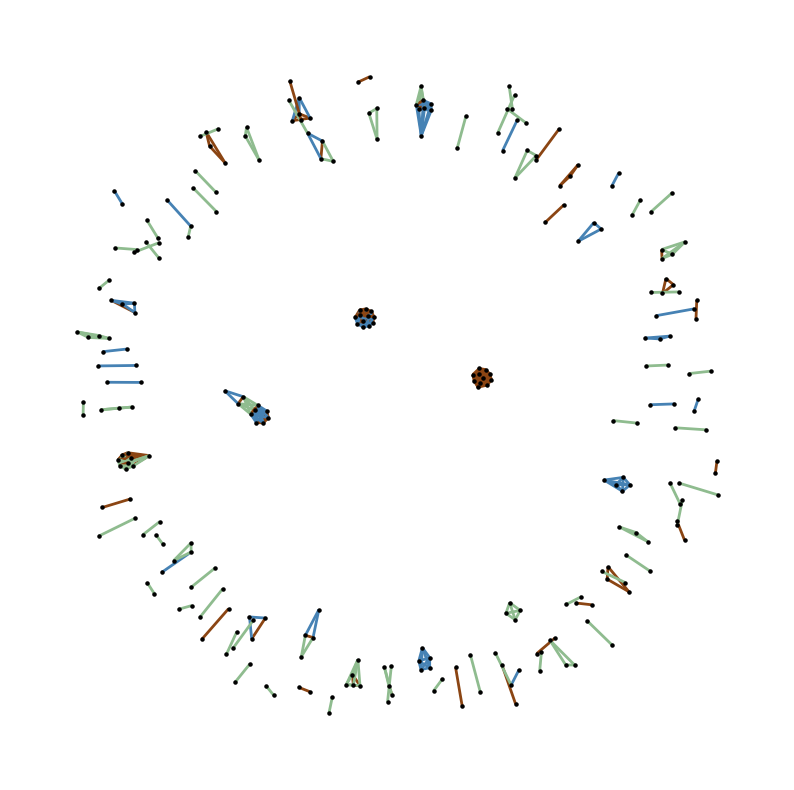

In [ ]:
# foldseek_clustered_gene_ids = foldseek_cluster_df[foldseek_cluster_df.cluster_size > 1].gene_id.values 
# mmseqs_clustered_gene_ids = mmseqs_cluster_df[mmseqs_cluster_df.cluster_size > 1].gene_id.values 
# foldseek_singleton_gene_ids = foldseek_cluster_df[foldseek_cluster_df.cluster_size == 1].gene_id.values 
# mmseqs_singleton_gene_ids = mmseqs_cluster_df[mmseqs_cluster_df.cluster_size == 1].gene_id.values 
# singleton_gene_ids = np.intersect1d(mmseqs_singleton_gene_ids, foldseek_singleton_gene_ids)

# print('Number of proteins in a cluster (Foldseek):', len(foldseek_clustered_gene_ids))
# print('Number of proteins in a cluster (MMseqs):', len(mmseqs_clustered_gene_ids))
# print('Number of proteins in Foldseek clusters, not MMseqs clusters:', (~np.isin(foldseek_clustered_gene_ids, mmseqs_clustered_gene_ids)).sum())
# print('Number of proteins in MMseqs clusters, not Foldseek clusters:', (~np.isin(mmseqs_clustered_gene_ids, foldseek_clustered_gene_ids)).sum())

# cluster_graph = nx.Graph()
# # cluster_graph.add_nodes_from(genes_df.index.values)

# edges = dict()

# for cluster_id, df in foldseek_cluster_df.groupby('cluster_id'):
#     for i, j in itertools.combinations(df.gene_id.values, 2):
#         i, j = sorted([i, j])
#         edges[(i, j)] = 'steelblue'

# for cluster_id, df in mmseqs_cluster_df.groupby('cluster_id'):
#     for i, j in itertools.combinations(df.gene_id.values, 2):
#         i, j = sorted([i, j])
#         if (i, j) in edges: 
#             edges[(i, j)] = 'saddlebrown'
#         else:
#             edges[(i, j)] = 'darkseagreen'
# cluster_graph.add_edges_from(list(edges.keys()))


# fig, ax = plt.subplots(figsize=(10, 10))
# pos = nx.spring_layout(cluster_graph, k=0.12) 
# nx.draw_networkx_nodes(cluster_graph, pos=pos, ax=ax, node_color='black', node_size=5)
# nx.draw_networkx_edges(cluster_graph, pos=pos, ax=ax, edge_color=[edges[tuple(sorted(e))] for e in cluster_graph.edges], width=2)
# ax.set_axis_off()
# plt.show()

# cluster_df = list()
# clusters = sorted(list(nx.connected_components(cluster_graph)), key=len)[::-1] # Sort clusters in descending order by size. 
# for i, cluster in enumerate(clusters):
#     cluster_df += [{'gene_id':gene_id, 'cluster_id':i, 'cluster_size':len(cluster)} for gene_id in cluster]
# cluster_df += [{'gene_id':gene_id, 'cluster_id':i + j + 1, 'cluster_size':1} for j, gene_id in enumerate(singleton_gene_ids)]
# cluster_df = pd.DataFrame(cluster_df)
# cluster_df['genome_id'] = cluster_df.gene_id.apply(get_genome_id)
# cluster_df['cluster_num_genomes'] = cluster_df.cluster_id.map(cluster_df.groupby('cluster_id').apply(lambda df : df.genome_id.nunique(), include_groups=False))

# genes_df = genes_df.reset_index().copy()
# genes_df = genes_df.drop(columns=[col for col in genes_df.columns if (col in mmseqs_cluster_df.columns) and (col != 'gene_id')])
# genes_df = genes_df.merge(cluster_df, on='gene_id', how='left')
# genes_df = genes_df.set_index('gene_id')